# CVaR-MDPs: Algorithm 2 and Experiments

This code includes the implementation of the main algorithm (CVaR Value Iteration with Linear Interpolation) and experiments that were performed with it (as described in the work).

## Contents of the Code

| Part | Contents of this Code |
| --- | --- |
| 1 | Notation and basic components |
| 2 | Sub-maximization problem of the interpolated Bellman operator |
| 3 | Bellman-sweep and Grid-adaption |
| 4 | Algorithm: Value iteration with linear interpolation |
| 5 | Optimal policy |
| 6 | Grid-World: Map, MDP, Perturbation |
| 7 | Monte-Carlo-Simulation |
| 8 | Experiments |


## Notation

| Symbol | Interpretation |
|---|---|
| `P` | tensor `(nA, nX, nX)` with `P[a,x,x'] = P(x'\|x,a)` |
| `C` | matrix `(nX, nA)` with deterministic costs `C(x,a)` |
| `Y` | list of `nX` arrays; `Y[x]` are interpolation points $y_1=0<\dots<y_{N(x)}=1$ |
| `V` | list of `nX` arrays; `V[x][i]` $= V(x, y_i)$ |
| `gamma` | discount factor $\gamma$ |
| `theta` | log-distance of interpolation points, $y_{i+1}=\theta y_i$ |
| `eps` | error tolerance $\epsilon$ from theorem 4.2.6 |

---
# 1 - Basic components

In [1]:
import numpy as np
import scipy.optimize

## 1.1 Starting grid

The interpolation points fulfill $y_1 = 0$, $y_N=1$ and $y_{i+1}=\theta y_i$ ($i \ge 2$). Constructing these $y$ backwards from $y_N=1$ on, one gets $y_2 = \theta^{-(N-2)}$.

Note that the standard starting grid, that was used, is with $N=21$ and $\theta=2.067$, and by that, $y_2 \approx 10^{-6}$.

In [2]:
def starting_grid(N, theta):    # create a log spaced interpolation grid (in y) depending on theta
    """interpolation points y_1=0 < y_2 < ... < y_N=1 mit y_{i+1} = theta*y_i (i>=2)."""
    ys = np.ones(N)
    for i in range(N-1, 0, -1):
        ys[i-1] = ys[i]/theta
    ys[0] = 0.0
    return ys

## 1.2 Evaluation of the value function

Note that the core of the method is the interpolation of $y\,V(x,y)$, **not** $V(x,y)$. The exact interpolation formula of $y\,V(x,y)$ can be found in chapter 4.2 above. 

In [4]:
def value_at(x, y, V, Y):
    """V(x,y) for an arbitrary x and y in [0,1] via interpolation of y*V(x,y)"""
    if y <= 0:
        return V[x][0]
    return float(np.interp(y, Y[x], Y[x]*V[x])/y)

---
# 2 - Sub-maximization problem of the interpolated Bellman operator

The definition of the interpolated Bellman operator, and by that of the sub-maximizatioin problem, can be found in chapter 5.1 above. Additionally, the transformation of this subproblem into its two different forms for linear programming and a waterfilling algorithm can be found there.

In [5]:
def subproblem_lp(y, probs, succ, V, Y, return_z=False):
    """
    - solution of the sub-maximization problem with linear programming.
    - variables: z_0,...,z_{l-1} (= y*xi) and auxiliary variables t_0,...,t_{l-1} (= f_i(z_i)).
    - note: for every y separatly -> no vectorization possible
    """
    l = len(succ)
    rows, rhs = [], []
    for i, xp in enumerate(succ):
        Yx = Y[xp]
        yV = Yx*V[xp]
        slopes = np.diff(yV)/np.diff(Yx)    # calculate slopes of piecew. linear, concave functions
        intercepts = yV[:-1] - slopes*Yx[:-1]   # calculate intersection with axis (for  constraints)
        for s, b in zip(slopes, intercepts):
            row = np.zeros(2*l)
            row[l+i] = 1.0
            row[i] = -s
            rows.append(row); rhs.append(b)

    obj = np.zeros(2*l); obj[l:] = -probs   # max sum p_i t_i  (division by y later); (obj = (z_1, ..., z_l, t_1, ..., t_l))
    A_eq = np.zeros((1, 2*l)); A_eq[0, :l] = probs  # equality constraints are prepared
    bounds = [(0.0, 1.0)]*l + [(None, None)]*l

    res = scipy.optimize.linprog(obj,   # obj. fct.
                                 np.array(rows), np.array(rhs), # inequality constraints
                                 A_eq, np.array([y]), bounds)   # equality constraints and bounds
    if not res.success:
        raise RuntimeError("LP failed: " + res.message)
    value = -res.fun/y   # scaling in the end due to bad conditioning otherwise
    return (value, res.x[:l]) if return_z else value

In [6]:
def subproblem_waterfill(y, probs, succ, V, Y, return_z=False, segs=None):
    """
    - solution of sub-maximization problem by waterfilling (for fixed y) -> vectorized version is built in later; this version here is only used for greedy_policy.
    - note: segs are optionally pre-calculated (slopes, widths) per state (see segments() -> faster)
    - this function shows in an instrucive way the idea of waterfilling
    """
    if segs is None:
        segs = segments(V, Y)

    slopes = np.concatenate([segs[s][0] for s in succ]) # returns one vector with the slopes of all successors
    caps = np.concatenate([segs[s][1]*probs[i] for i, s in enumerate(succ)])    # returns "capacities" (here: segment width * probability)
    owner = np.concatenate([np.full(len(segs[s][0]), i) for i, s in enumerate(succ)])

    o = np.argsort(-slopes, kind="stable")  # sort slopes descendign -> hence -slopes ; returns indices
    slopes, caps, owner = slopes[o], caps[o], owner[o]  # returns the by slope sorted slopes, caps, and owner 

    cum = np.cumsum(caps)   # budget AFTER item j
    cum0 = np.concatenate([[0.0], cum[:-1]])    # budget BEFORE item j
    gain0 = np.concatenate([[0.0], np.cumsum(slopes*caps)[:-1]])

    k = min(int(np.searchsorted(cum, y, side="left")), len(slopes)-1)   # np.searchsorted(array, y) returns index where y would be sorted into the array
    value = (gain0[k] + slopes[k]*(y - cum0[k]))/y   # based on index k until where one can fill up, calculate fill value (gain until k + rest until y)

    if not return_z:
        return value
    gefuellt = np.clip(y - cum0, 0.0, caps)
    z = np.bincount(owner, weights=gefuellt/probs[owner], minlength=len(succ))
    return value, z

---
# 3 — Bellman-sweep and Grid-adaption

## 3.1 Pre-calculations

Two factors can be pulled out of the inner loops of the interpolated value iteration algorithm due to their independence of $y$: 

* **`segments`**: The segment slopes and widhts of $f_i$ only depend on `(V[x'], Y[x'])`, not of $x$, $a$ or $y$ -> hence calculated once per sweep
* **`support`**: The support of $P(\cdot|x,a)$ only depends on `P`, $x$ and $a$ -> calculated once

In [7]:
def segments(V, Y):
    """(slopes, widths) of the piecewise-linear interpolation of y*V(x,y)"""
    return [(np.diff(Y[x]*V[x])/np.diff(Y[x]), np.diff(Y[x])) for x in range(len(Y))] 
# array with arrays that include for every y in Y[x] slope and width of the section that starts at y (for x)

def support(P):
    """support(P)[a][x] = indices of the x' with P(x'|x,a) > 0 (axes as for P)"""
    nA, nX, _ = P.shape
    return [[np.nonzero(P[a, x] > 0)[0] for x in range(nX)] for a in range(nA)]

## 3.2 One sweep $V \mapsto T_I[V]$

The waterfilling method enables a vectorization of the algorithm that can not be performed for the LP: the **sorting order of the segments does not depend on $y$**. Per $(x,a)$ **one** `argsort` suffices and all interpolation points $y_i$ can be processed with one `searchsorted`

For `method="lp"` this advantage does not exist and per $(x, y_i, a)$ one LP has to be solved. Hence, this variant is only used as reference, not for experiments.

Note: For $y=0$ it holds $T_I[V](x,0) = \min_a\{C(x,a) + \gamma \max_{x': P(x'|x,a)>0} V(x',0)\}$.

In [8]:
def bellman_sweep(V, Y, P, C, gamma, supp=None, method="waterfill"):
    """Eine Anwendung von T_I auf alle (x, y_i). Gibt die neue Liste V zurueck."""
    nA, nX, _ = P.shape
    if supp is None:
        supp = support(P)
    segs = segments(V, Y)
    V_new = [None]*nX   # initialize new vector for value function

    for x in range(nX):
        ys = Y[x]
        pos = ys > 0    # tells where y≠0 as boolean vector
        best = np.full(len(ys), np.inf) # here the values are stored for every a

        for a in range(nA):
            S = supp[a][x]
            probs = P[a, x, S]
            sub = np.empty(len(ys))
            sub[~pos] = max(V[s][0] for s in S) # definition of bellman op. for y=0

            if method == "waterfill":   # vectorized variant of waterfill (see above)
                # one argsort per (x,a) -> applies to all y at the same time -> significantly faster than lp because of vectorization
                slopes = np.concatenate([segs[s][0] for s in S])
                caps = np.concatenate([segs[s][1]*probs[i] for i, s in enumerate(S)])
                o = np.argsort(-slopes, kind="stable")
                slopes, caps = slopes[o], caps[o]
                cum = np.cumsum(caps)
                cum0 = np.concatenate([[0.0], cum[:-1]])
                gain0 = np.concatenate([[0.0], np.cumsum(slopes*caps)[:-1]])
                k = np.clip(np.searchsorted(cum, ys, side="left"), 0, len(slopes)-1)    # can be calculated for all y at the same time
                sub[pos] = (gain0[k[pos]] + slopes[k[pos]]*(ys[pos]-cum0[k[pos]]))/ys[pos]  # gain0[...] are the "full" segments, slopes(k[pos])*(ys[pos]-cum0[k[pos]]) is the segment that is only used a bit (such that cum resp. the capacities are filled up to level ys[pos])
            elif method == "lp":
                for j in np.nonzero(pos)[0]:
                    sub[j] = subproblem_lp(ys[j], probs, S, V, Y)
            else:
                raise ValueError("method must be 'waterfill' or 'lp'")

            best = np.minimum(best, C[x, a] + gamma*sub)
        V_new[x] = best
    return V_new

## 3.3 Grid-adapation

As theorem 4.2.6 demands $V_t(x,y_2) - V_t(x,0) \ge -\epsilon$, a grid-adaption might be needed. This is done as described in chapter 4.2.

In [9]:
def refine_grid(Yx, Vx, eps, theta, y_min=1e-12, max_points=300):
    """
    - grid adaption function 
    - inserts interpolation points in [0, y_2] if |V(x,y_2) - V(x,0)| > eps.
    - returns (Y_new, V_new, changed).
    """
    if len(Yx) < 2:
        return Yx, Vx, False

    y2 = Yx[1]
    dist = abs(Vx[1] - Vx[0])
    if dist <= eps or y2 <= y_min or len(Yx) >= max_points: # check whether adapation shall take place
        return Yx, Vx, False

    # when adaption can take place, calculate new y_2' and insert new log-spaced points between y_2' and the old y_2
    y2_new = max(eps*y2/dist, y_min)    
    new_points = [y2_new]
    while new_points[-1]*theta < y2:  # insert new y-values according to log-dist rule
        new_points.append(new_points[-1]*theta)

    Y_new = np.concatenate(([0.0], new_points, Yx[1:]))
    V_new = np.concatenate(([Vx[0]], np.full(len(new_points), Vx[1]), Vx[1:]))  # new y-values get the value of the ols y_2 as value
    return Y_new, V_new, True

---

# 4 - Algorithm: Value iteration with linear interpolation

As starting value function $V_0 \equiv 0$ is used as it fulfills the assumptions needed (i.e. $y V_0 \equiv 0$ is concave and continuous).

The iteration is stopped when the residual distance `diff` falls beneath `tol`. From the contraction property the **a-posteriori bound**

$$\|V_n - \hat V^*\|_\infty \le \frac{\gamma}{1-\gamma}\,\texttt{diff},$$

follows, which is returned by the function.


In [10]:
def cvar_value_iteration(P, C, gamma=0.95, N=21, theta=2.067, eps=0.1,
                         tol=1e-6, maxit=20000, method="waterfill",
                         adapt=True, y_min=1e-12):
    """
    - algorithm 2 from the work above (algorithm 1 in the paper)
    - y_min : lower bound for grid adaptionuntere Schranke fuer die Gitteradaption (only relevant for method="lp")
    - returns: dict with
        V, Y        value function and interpolation points
        iterations  number of sweeps
        residual    last residual dist (max_x ||V_new - V_old||_inf)
        bound       a-posteriori-bound gamma/(1-gamma) * residual
        converged   whether tol was reached or not
        y2_min      smalles y_2 over all states (diagnosis of the grid adaption)
    """
    nA, nX, _ = P.shape
    Y = [starting_grid(N, theta) for _ in range(nX)]    # initialize starting y-values for every x
    V = [np.zeros(N) for _ in range(nX)]    # choose V_0 = 0 as initial value function
    supp = support(P)   # choose those x' that can be reached from x (see above)

    diff = np.inf
    for it in range(maxit):
        V_new = bellman_sweep(V, Y, P, C, gamma, supp, method)
        diff = max(np.max(np.abs(V[x]-V_new[x])) for x in range(nX))
        V = V_new

        if adapt:   # adapt grid if wanted
            for x in range(nX):
                Y[x], V[x], _ = refine_grid(Y[x], V[x], eps, theta, y_min=y_min)

        if diff <= tol: # convergence noted? -> break
            break

    return dict(V=V, Y=Y, iterations=it+1, residual=diff,
                bound=gamma/(1-gamma)*diff, converged=bool(diff <= tol),
                y2_min=float(min(Yx[1] for Yx in Y)))

---

# 5 - Optimal policy

The optimal policy is Markov on the **augmented state space**:

$$a_k = u^*(x_k, y_k),\qquad y_k = y_{k-1}\,\xi^*(x_k),\qquad y_0 = \alpha.$$

The function `greedy_policy` delivers both: the action and the new confidence levels $y' = z$ for all accessible successors. Note that `z` is already $y\,\xi$, hence the new confidence level not only the factor $\xi$.

In [11]:
def greedy_policy(x, y, V, Y, P, C, gamma, segs=None, method="waterfill"):
    """
    - implements the derivation of the greedy policy
    - input: (optimal) value function; mdp parameters, (x, y)
    - returns: (a, y_next) with y_next as dict {x': y'}, only on the support
    """
    nA = P.shape[0]
    if segs is None and method == "waterfill":
        segs = segments(V, Y)

    best_val, best_a, best_S, best_z = np.inf, 0, None, None
    for a in range(nA):
        S = np.nonzero(P[a, x] > 0)[0]
        probs = P[a, x, S]
        # solve sub-max-problem (y=0? and optimization method -> case distinction)
        if y <= 0:
            sub, z = max(V[s][0] for s in S), np.zeros(len(S))  # def of bellman op for y=0
        elif method == "waterfill":
            sub, z = subproblem_waterfill(y, probs, S, V, Y, return_z=True, segs=segs)
        else:
            sub, z = subproblem_lp(y, probs, S, V, Y, return_z=True)

        val = C[x, a] + gamma*sub   
        if val < best_val:  # choose the a that has the best val
            best_val, best_a, best_S, best_z = val, a, S, z

    return best_a, {int(xp): float(zi) for xp, zi in zip(best_S, best_z)}

---

# 6 - Grid-World: Map, MDP, Perturbation

## 6.1 Map

A `Map` is an object that consists of the grid size, a set of obstacles, start and goal. Everything that is random is created with `np.random.default_rng(seed)` and is by that reproducible.
Note: It is tested whether a obstacle-free path from start to goal exists; if not the next seed is used. 

In [12]:
from collections import deque   # needed for BFS
from dataclasses import dataclass, field    # needed to create dataclass Map

MOVES = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # up, down, left, right


@dataclass  # create new dataclass map that includes all information needed
class Map:  # position on the map is stored as (r, c)=(row, column) -> four directions where the agent can move from there on
    H: int  # hight of map
    W: int  # width of map
    obstacles: frozenset    # set of points that are obstacles
    start: tuple    # starting point
    goal: tuple # end/goal point

    def is_free(self, cell):    # checks whether a cell is free
        return cell not in self.obstacles


def _path_exists(H, W, obstacles, start, goal): # checks for at least one obstacle free path from start to goal by applying BFS over the free cells
    if start in obstacles or goal in obstacles:
        return False
    seen, q = {start}, deque([start])   # seen includes the visited cells, q is the queue of the cells that are to be visited next
    # start breadth-first-search method
    while q:
        r, c = q.popleft()
        if (r, c) == goal:
            return True # stops search as soons as a cell is found thats neighbouring goal
        for dr, dc in MOVES:    # for all possible neighbours check whether they are feasible and add them to the queue if they are
            nb = (r+dr, c+dc)
            if 0 <= nb[0] < H and 0 <= nb[1] < W and nb not in obstacles and nb not in seen:    # check neighbours for obstacles or edges of map
                seen.add(nb); q.append(nb)
    return False


def make_map(seed, H=20, W=20, obst_frac=0.12, start=(0, 0), goal=None, max_tries=100):
    """
    - random map with obst_frac*H*W obstacles (reproducible via seed)
    - start and goal stay always free; a existing obstacle-free path is guaranteed
    """
    goal = goal if goal is not None else (H-1, W-1) # goal is lower right corner if not given otherwise
    n_obst = int(round(obst_frac*H*W))  # number of obstacles
    candidates = [(r, c) for r in range(H) for c in range(W) if (r, c) not in (start, goal)]    # select candidates for obstacles

    for t in range(max_tries):  # some maps maybe not possible due to too many obstacles
        rng = np.random.default_rng((seed, t))  # reproducible; t is trial number 
        pick = rng.choice(len(candidates), n_obst, replace=False)   # selects n_obst random obstacles from candidates (bool)
        obstacles = frozenset(candidates[i] for i in pick)  # obstacles stored as set
        if _path_exists(H, W, obstacles, start, goal):  # check whether an obstacle-free path exists
            return Map(H, W, obstacles, start, goal)
    raise RuntimeError(f"no feasible layout after {max_tries} attempts (obst_frac too high?)")

## 6.2 Map $\to$ MDP

1. **state space**: all $H\cdot W$ grid cells plus two absorbing states `GOAL` and `DEAD` (in total $402$ for $20\times20$).

2. **costs**: `C(x,a)` only depends on the state where the agent **is**, the collision costs are assigned to the obstacle state, not the transition to it!!!

    | state | `C(x,a)` | transition |
    |---|---|---|
    | free cell | `c_step` | neighbours acc. to noise |
    | obstacle cell | `c_coll` | $\to$ `DEAD` |
    | goal cell | `0` | $\to$ `GOAL` |
    | `GOAL`, `DEAD` | `0` | self-looping |

    The collision costs are paid once (at the time of hitting the obstacle), are discounted with $\gamma^t$ and the episode ends (-> like in the paper: "hitting an obstacle costs $M\gg1$ and terminates the mission").

3. **noise.**: With probability $1-p_{\rm noise}$ the agent gets to the wanted cell, with $p_{\rm noise}$, uniformly distributed, the agent gets to one of the other three cells. A move out of the grid makes the agent stop. 

4. **standard `c_coll`:** $M = 2/(1-\gamma)$ as in the paper (i.e. $40$ bei $\gamma=0.95$).

In [13]:
def map_to_mdp(m, gamma=0.95, p_noise=0.05, c_step=1.0, c_coll=None):
    """
    - builds (P, C) and the index information from a map
    - returns: dict with
        P, C        inputs for cvar_value_iteration
        index       {(r,c): x} for the grid cells
        GOAL, DEAD  indices of the two absorbing states
        map, gamma, ...  the used parameters (for the simulation)
    """
    c_coll = 2.0/(1.0-gamma) if c_coll is None else c_coll
    H, W = m.H, m.W
    cells = [(r, c) for r in range(H) for c in range(W)]    # positions on the map are brought into vector form
    index = {cell: i for i, cell in enumerate(cells)}   # index is built: integer index is assigned to (r,c) (as dictionary)
    GOAL, DEAD = H*W, H*W + 1   # two additional virtual states GOAL and DEAD are introduced (with the last two indices)
    nX, nA = H*W + 2, 4 # H*W states plus the goal and virtual dead state

    # initialize P and C
    P = np.zeros((nA, nX, nX))
    C = np.zeros((nX, nA))

    for (r, c) in cells:
        x = index[(r, c)]
        # always 3 possible cases: either a state is the goal, an obstacle or a "normal" cell -> assign the fitting costs and transition probs.

        # 1) (r,c) is the goal
        if (r, c) == m.goal:    # goal: absorbing (after goal no more costs occure) and cost-free
            P[:, x, GOAL] = 1.0
            continue

        # 2) (r,c) ist hindernis
        if (r, c) in m.obstacles:   # obstacle: once c_coll, then termination
            P[:, x, DEAD] = 1.0 # obstacles terminate the episode -> lead to virtual DEAD state
            C[x, :] = c_coll    # obstacles cost c_coll
            continue

        # 3) (r,c) is "normal" cell
        C[x, :] = c_step    # free cell
        for a in range(nA):
            for b, (dr, dc) in enumerate(MOVES):
                prob = (1.0-p_noise) if a == b else p_noise/3.0 # agent moves with 5% in unwanted direction
                nr, nc = r+dr, c+dc
                if not (0 <= nr < H and 0 <= nc < W):   # edge: dont move + the probs are not assigned to x' but x
                    nr, nc = r, c   
                P[a, x, index[(nr, nc)]] += prob
    # self-looping when agent is in GOAL or DEAD
    P[:, GOAL, GOAL] = 1.0
    P[:, DEAD, DEAD] = 1.0

    assert np.allclose(P.sum(axis=2), 1.0), "P is not row-stochastic"  # check P for stochasticity
    return dict(P=P, C=C, index=index, GOAL=GOAL, DEAD=DEAD, map=m,
                gamma=gamma, p_noise=p_noise, c_step=c_step, c_coll=c_coll)

## 6.3 Perturbation of the Map

Mainly for experiment 3 needed: every obstacle is moved to a neighbouring cell with probability `p_map`. Such a movement is not performed if it would lead out of the map, to start/goal or to a already taken (by obstacle) cell. Start start, goal and grid size stay unchanged, as well as the number of obstacles. 

In [14]:
def perturb_map(m, p_map=0.5, seed=0):
    """
    - moves every obstacle with prob p_map to neighbouring cell (reproducible via seed)
    - number of obstacles stays constant
    """
    rng = np.random.default_rng(seed)
    occupied = set(m.obstacles) # currently taken cells
    new_obstacles = set()

    for cell in sorted(m.obstacles):    # sorted => seed-stable
        occupied.discard(cell)  # this obstacle releases its cell
        target = cell
        if rng.random() < p_map:    # change obstacle with prob p_map
            dr, dc = MOVES[rng.integers(4)] # choose random move
            candidate = (cell[0]+dr, cell[1]+dc)    # new candidate as obstacle
            if (0 <= candidate[0] < m.H and 0 <= candidate[1] < m.W
                    and candidate not in (m.start, m.goal)
                    and candidate not in occupied):    # new obstacle must be on grid, may not be taken or goal/start
                target = candidate
        new_obstacles.add(target)
        occupied.add(target)

    return Map(m.H, m.W, frozenset(new_obstacles), m.start, m.goal)

---
# 7 — Monte-Carlo-Simulation

Simulates trajectories under the optimal policy and measures the realised discounted total costs $\sum_t \gamma^t C(x_t,a_t)$.

A few notes: 

1. **$y$ is carried along**: After every step $y$ is updated on the new confidence level returned by the sub-maximization problem.

2. **`mdp_eval` separates policy and dynamics**: The action and $y$-update always come from the "nominal" model, the transitions are sampled from `mdp_eval` (needed for experiment 3).

3. **modelling decision**: Under model mismatch the realised successor might be outside of the "nominal" support (e.g. when a cell is nominally an obstacle but free on the perturbed map). Then the sub-max-problem delivers no $y$ and one has to define how to continue: 

    * `y_offsupport="zero"` (Standard): $y'=0$, the policy becomes maximally risk avers which is conservative and consistend with the CVaR-interpretation.
    * `y_offsupport="keep"`: $y$ stays unchanged

In [15]:
def simulate(res, mdp, alpha, n_runs=500, seed=0, mdp_eval=None, max_steps=400,
             y_offsupport="zero"):
    """
    - Monte-Carlo-simulation of optimal policy at confidence level alpha (needed for experiment 1 and 3)
    - inputs: 
        res           : return of cvar_value_iteration (nominales Modell)
        mdp           : nominal MDP-dict (delivers policy)
        mdp_eval      : optionally differing MDP for dynamics and costs (exp. 3) -> perturbed map
        y_offsupport  : "zero" or "keep" -> behaviour when realized successors lies out of nominal map (see above)
    - returns: dict with costs, failure_rate, success_rate, timeout_rate,
               mean_cost_success, mean_length_success
    """
    V, Y = res["V"], res["Y"]
    P, C, gamma = mdp["P"], mdp["C"], mdp["gamma"]
    P_eval = (mdp_eval or mdp)["P"]
    C_eval = (mdp_eval or mdp)["C"]
    supp_eval = support(P_eval) # sampling only over support
    GOAL, DEAD = mdp["GOAL"], mdp["DEAD"]
    x0 = mdp["index"][mdp["map"].start]

    segs = segments(V, Y)   # calculated once
    rng = np.random.default_rng(seed)

    costs, lengths, ends = [], [], []
    for _ in range(n_runs): # number of simulations run
        x, y, total, disc, t = x0, alpha, 0.0, 1.0, 0
        while t < max_steps:    # using the greedy policy to find a cheap path
            a, y_next = greedy_policy(x, y, V, Y, P, C, gamma, segs=segs)   # returns a and possible next states x' with new y'
            total += disc*C_eval[x, a]   # sum up discounted costs
            disc *= gamma   # discountfactor disc=gamma^t wird durch schleife produziert
            t += 1
            S = supp_eval[a][x]
            x_new = int(rng.choice(S, p=P_eval[a, x, S]))   # random process that "chooses"/determines the next states out of the possible ones
            fallback = 0.0 if y_offsupport == "zero" else y
            # update (x,y) for the next iteration/step
            y = y_next.get(x_new, fallback) # in case that x_new is not in nominal support -> choose y_new=y=fallback, else y=y_new from y_next belonging to x_new
            x = x_new
            if x == GOAL or x == DEAD:  # stop if goal is reached
                break
        # update total costs, total length, and failure/no failure of the run
        costs.append(total)
        lengths.append(t)
        ends.append("goal" if x == GOAL else ("dead" if x == DEAD else "timeout"))

    costs = np.array(costs); lengths = np.array(lengths); ends = np.array(ends)
    ok = ends == "goal"
    return dict(costs=costs, lengths=lengths, ends=ends,
                failure_rate=float(np.mean(ends == "dead")),
                success_rate=float(np.mean(ok)),
                timeout_rate=float(np.mean(ends == "timeout")),
                mean_cost=float(costs.mean()),
                mean_cost_success=float(costs[ok].mean()) if ok.any() else np.nan,
                mean_length=float(lengths.mean()),
                mean_length_success=float(lengths[ok].mean()) if ok.any() else np.nan)


def empirical_cvar(costs, alpha):   # definition of the empirical cvar implemented as function
    """CVaR_alpha der Stichprobe: Mittel der schlechtesten ceil(alpha*n) Werte."""
    z = np.sort(np.asarray(costs))
    if alpha >= 1.0:
        return float(z.mean())
    k = max(1, int(np.ceil(alpha*len(z))))
    return float(z[-k:].mean())

---

# 8 - Experiments

## 8.1: Experiment 1: Variation of the risk parameter $\alpha$

This experiment examines the risk behaviour of the CVaR poliy (depending on $\alpha$) by solving the problem for different maps and then running simulations of the optimal policies.

  map 0: 685 sweeps, 55s, bound 4.9e-05
  map 1: 685 sweeps, 55s, bound 4.9e-05
  map 2: 685 sweeps, 102s, bound 4.9e-05
  map 3: 685 sweeps, 55s, bound 4.9e-05
  map 4: 685 sweeps, 70s, bound 4.9e-05
  map 5: 685 sweeps, 55s, bound 4.9e-05
  map 6: 685 sweeps, 57s, bound 4.9e-05
  map 7: 685 sweeps, 55s, bound 4.9e-05
  map 8: 685 sweeps, 68s, bound 4.9e-05
  map 9: 685 sweeps, 55s, bound 4.9e-05

Experiment 1 - 10 maps, 2000 Monte-Carlo runs per (map, alpha)
mean over non-degenerate maps; 'timeout_rate' and 'degenerate' over all maps
         V_x0    cost  path_length  collision_rate  cvar_emp  timeout_rate  degenerate
alpha                                                                                 
1.00   28.487  27.959       41.598           0.011    28.501         0.000         0.0
0.50   29.525  28.083       41.883           0.009    29.806         0.000         0.1
0.20   31.210  28.244       42.269           0.004    31.103         0.002         0.2
0.10   33.260  28.311  

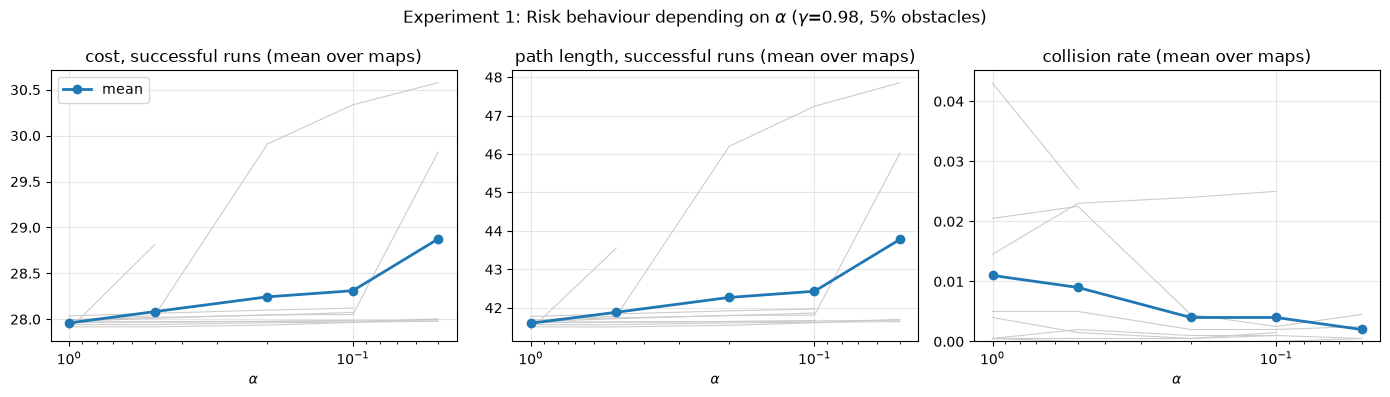

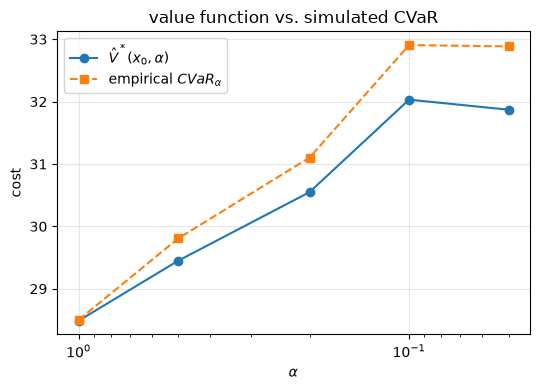

In [16]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# common parameters for all following experiments!!!
PARAMS = dict(H=20, W=20, obst_frac=0.05, gamma=0.98,
              p_noise=0.05, c_step=1.0, c_coll=None)   # c_coll=None -> 2/(1-gamma) = 100 due to definitoin in map_to_mdp
ALPHAS = [1.0, 0.5, 0.2, 0.1, 0.05] # alpha=0.01 degenerates (alpha=0.05 slightly deg. already)
TOL = 1e-6


def mdp_from_map(m, **kw):
    """Map -> MDP mit den Parametern aus PARAMS."""
    p = {**PARAMS, **kw}    # kw represents additional keywords -> PARAMS dict and kw dict are joined, when there are overlaps, kw wins
    return map_to_mdp(m, gamma=p["gamma"], p_noise=p["p_noise"],
                      c_step=p["c_step"], c_coll=p["c_coll"])


def build_and_solve(seed, **kw):    # all-in-one function -> map, mdp, solution
    """Map -> MDP -> Wertefunktion. Ein Aufruf pro Map, gueltig fuer alle alpha."""
    p = {**PARAMS, **kw}    # see above
    m = make_map(seed, H=p["H"], W=p["W"], obst_frac=p["obst_frac"])
    mdp = mdp_from_map(m, **kw)
    res = cvar_value_iteration(mdp["P"], mdp["C"], gamma=p["gamma"], tol=TOL)
    return m, mdp, res


# --- Episode
N_MAPS, N_RUNS = 10, 2000   # how often should experiment be run (number of maps and number of monte-carlo runs)

rows = []
for seed in range(N_MAPS):
    t0 = time.time()    # start of time measurement
    m, mdp, res = build_and_solve(seed) # build and solve an mdp
    x0 = mdp["index"][m.start]
    for alpha in ALPHAS:
        s = simulate(res, mdp, alpha, n_runs=N_RUNS, seed=1000+seed)
        # each row represents the results of the simulations for one map
        rows.append(dict(
            seed=seed, alpha=alpha,
            V_x0=value_at(x0, alpha, res["V"], res["Y"]),   # theoretical cost value
            cost=s["mean_cost_success"],    # "real" costs of successful runs
            path_length=s["mean_length_success"],   # average path length during simulations
            collision_rate=s["failure_rate"],   # rate of failure during simulations -> collisions
            timeout_rate=s["timeout_rate"], # rate of timeout during simulations
            cvar_emp=empirical_cvar(s["costs"], alpha)))    # empirical cvar is calculated for the simulations of the current map
    print(f"  map {seed}: {res['iterations']} sweeps, {time.time()-t0:.0f}s, "
          f"bound {res['bound']:.1e}")

exp1 = pd.DataFrame(rows)   # raw result data from simulations for different maps

# a degenerate map for some alpha occurs when the policy "parks" somewhere, i.e. stops going for the goal -> timeout_rate > 0 --> this influences the path length + collision rate column, so these metrics are only averaged over non-degenerate cases
METRICS = ["cost", "path_length", "collision_rate", "cvar_emp"] # come from simulation
nondeg = exp1["timeout_rate"] == 0.0 # filter out degenerate ones
tab1 = exp1[nondeg].groupby("alpha")[METRICS].mean().reindex(ALPHAS)

# the following are averaged over all maps
tab1.insert(0, "V_x0", exp1.groupby("alpha")["V_x0"].mean())    # the V_x0 comes from value function not from simulation -> average over all maps
tab1["timeout_rate"] = exp1.groupby("alpha")["timeout_rate"].mean() # all maps
tab1["degenerate"] = exp1.groupby("alpha")["timeout_rate"].apply(
    lambda s: float((s > 0).mean()))    # share of maps that are degenerate
tab1 = tab1.sort_index(ascending=False).round(3)

print(f"\nExperiment 1 - {N_MAPS} maps, {N_RUNS} Monte-Carlo runs per (map, alpha)")
print("mean over non-degenerate maps; 'timeout_rate' and 'degenerate' over all maps")
print(tab1.to_string())

# --- Plots 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# the timeout rate is a diagnostic, not a performance metric -> it is reported in tab1
panels = [("cost", "cost, successful runs (mean over maps)", "mean"),
          ("path_length", "path length, successful runs (mean over maps)", "mean"),
          ("collision_rate", "collision rate (mean over maps)", "mean")]

for ax, (column, title, kind) in zip(axes.ravel(), panels):
    for _, g in exp1[nondeg].groupby("seed"):   # single maps as thin lines
        ax.plot(g["alpha"], g[column], color="0.8", lw=0.8, zorder=1)
    ax.plot(tab1.index, tab1[column], "o-", color="C0", lw=2, zorder=2, label=kind)
    ax.set_xscale("log"); ax.invert_xaxis() # more risk-averse from left to right
    ax.set_xlabel(r"$\alpha$"); ax.set_title(title); ax.grid(alpha=.3)
axes[2].set_ylim(bottom=0)
axes[0].legend()
fig.suptitle(f"Experiment 1: Risk behaviour depending on $\\alpha$ "
             f"($\\gamma$={PARAMS['gamma']}, {PARAMS['obst_frac']:.0%} obstacles)")
fig.tight_layout(); plt.show()


# Note: converged (theoretical?) value vs. empirical CVaR -> gap = interpolation error

# Note: here one cannot take tab1 as the V_x0 column is the average over all the different maps but the empirical cvar column is the average over the non-degenerate maps -> comparing makes no sense -> comp1 takes all into account
cmp1 = exp1[nondeg].groupby("alpha")[["V_x0", "cvar_emp"]].mean().sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(cmp1.index, cmp1["V_x0"], "o-", label=r"$\hat V^*(x_0,\alpha)$")
ax.plot(cmp1.index, cmp1["cvar_emp"], "s--", label=r"empirical $CVaR_\alpha$")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel("cost"); ax.grid(alpha=.3); ax.legend()
ax.set_title("value function vs. simulated CVaR")
fig.tight_layout(); plt.show()

## 8.2 Experiment 2: Approximation error and Runtime over N

Note that the grids of the respective runs are have no common points (besided 0, $y_2$, 1), hence, all solutions are compared on a **neutral evaluation grid** `y_eval`.

reference solution N=500 (theta=1.02813) ...
  685 sweeps, 71s, bound 4.9e-05

  N=   5  theta-1= 99.0000  error= 78.89652   19.5s
  N=  10  theta-1=  4.6234  error= 42.09302   19.9s
  N=  20  theta-1=  1.1544  error= 21.09573   20.7s
  N=  40  theta-1=  0.4384  error=  8.23977   22.9s
  N=  80  theta-1=  0.1938  error=  1.00400   25.9s
  N= 160  theta-1=  0.0914  error=  1.73109   35.1s

Experiment 2 - approximation error against reference N=500
  N     theta  theta_m1    error  max_excess   time_s  sweeps
  5 100.00000  99.00000 78.89652     0.00000 19.51784     685
 10   5.62341   4.62341 42.09302     0.00000 19.87682     685
 20   2.15443   1.15443 21.09573     0.00000 20.71885     685
 40   1.43845   0.43845  8.23977     0.00000 22.93177     685
 80   1.19378   0.19378  1.00400     0.29305 25.91912     685
160   1.09138   0.09138  1.73109     0.00291 35.06033     685

sign check (expected: V_N <= V_ref, since V_ref ~ V* and T_I <= T): largest excess = 2.93e-01


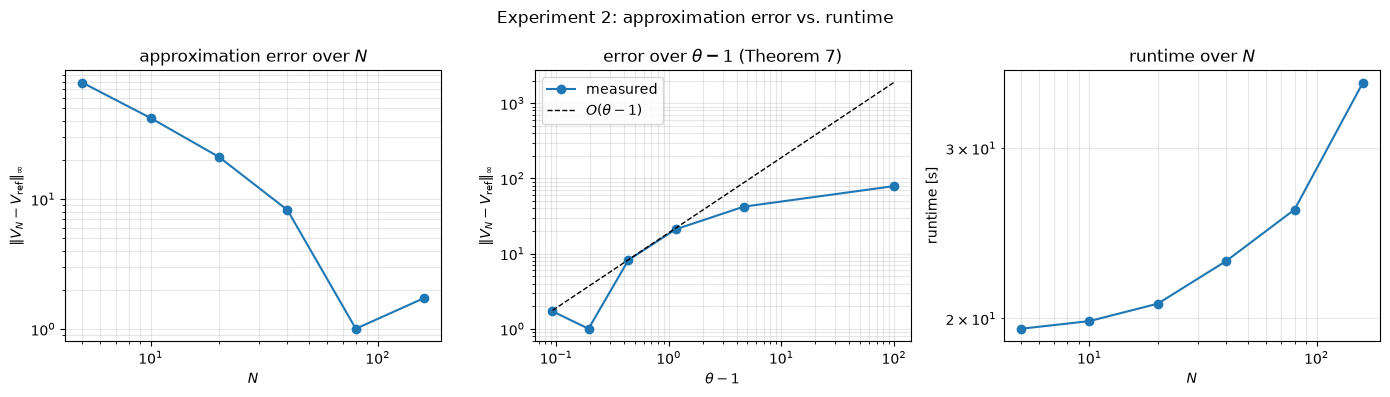

In [17]:
Y2_FIX = 1e-6   # standard N: (N=21 -> theta=2.067)
N_LIST = [5, 10, 20, 40, 80, 160]
N_REF = 500 # numerical reference solution -> represents V^*
SEED_EXP2 = 0

theta_from_N = lambda N: Y2_FIX**(-1.0/(N-2))

# build map and MDP once (without solving it, this is done later with variable N)
m2 = make_map(SEED_EXP2, H=PARAMS["H"], W=PARAMS["W"], obst_frac=PARAMS["obst_frac"])
mdp2 = mdp_from_map(m2)
nX2 = mdp2["P"].shape[1]

# neutral evaluation grid
y_eval = np.concatenate([[0.0], np.logspace(np.log10(Y2_FIX), 0.0, 40)])


def value_matrix(res):  # value function evaluated on evaluation grid
    """V(x,y) an den gemeinsamen Auswertepunkten, Form (nX, len(y_eval))."""
    return np.array([[value_at(x, y, res["V"], res["Y"]) for y in y_eval]
                     for x in range(nX2)])


def solve_with_N(N):    # function (only for exp 2) that returns a solution to an mdp (with mdp2 as input) with N interpolation points + calc. time
    t0 = time.time()
    r = cvar_value_iteration(mdp2["P"], mdp2["C"], gamma=PARAMS["gamma"],
                             N=N, theta=theta_from_N(N), tol=TOL, adapt=False)  # adapt=FALSE is important here (for obvious reasons)
    return r, time.time()-t0


print(f"reference solution N={N_REF} (theta={theta_from_N(N_REF):.5f}) ...")
ref, t_ref = solve_with_N(N_REF)
V_ref = value_matrix(ref)
print(f"  {ref['iterations']} sweeps, {t_ref:.0f}s, bound {ref['bound']:.1e}\n")

rows = []
for N in N_LIST:
    r, dt = solve_with_N(N)
    diff = value_matrix(r) - V_ref
    rows.append(dict(N=N, theta=theta_from_N(N), theta_m1=theta_from_N(N)-1.0,
                     error=float(np.max(np.abs(diff))),     # sup-Norm over all (x,y)
                     max_excess=float(np.max(diff)),        # ~0 for a fine reference
                     time_s=dt, sweeps=r["iterations"]))    # time for solution with N + number of iterations/sweeps
    print(f"  N={N:4d}  theta-1={rows[-1]['theta_m1']:8.4f}  "
          f"error={rows[-1]['error']:9.5f}  {dt:5.1f}s")

exp2 = pd.DataFrame(rows)   # raw data from experiment 2
print(f"\nExperiment 2 - approximation error against reference N={N_REF}")
print(exp2.round(5).to_string(index=False))
print(f"\nsign check (expected: V_N <= V_ref, since V_ref ~ V* and T_I <= T): "
      f"largest excess = {exp2['max_excess'].max():.2e}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# subplot 1: approx error over N
axes[0].loglog(exp2["N"], exp2["error"], "o-")
axes[0].set_xlabel("$N$"); axes[0].set_ylabel(r"$\|V_N-V_{\rm ref}\|_\infty$")
axes[0].set_title("approximation error over $N$")

# subplot 2: error over (theta-1) -> # both axes logarithmic scale (cf. Theorem 7 in paper)
axes[1].loglog(exp2["theta_m1"], exp2["error"], "o-", label="measured") # line1: actual error (x=theta-1, y=error)
ref_slope = exp2["error"].iloc[-1]/exp2["theta_m1"].iloc[-1]    
axes[1].loglog(exp2["theta_m1"], ref_slope*exp2["theta_m1"], "k--", lw=1,
               label=r"$O(\theta-1)$")  # line2: theoretical error (reference line, slope 1) -> (x=theta-1, y=ref_slope*(theta-1)=O(theta-1))
axes[1].set_xlabel(r"$\theta-1$"); axes[1].set_ylabel(r"$\|V_N-V_{\rm ref}\|_\infty$")
axes[1].set_title(r"error over $\theta-1$ (Theorem 7)"); axes[1].legend()

# subplot 3: runtime (in s) over N
axes[2].loglog(exp2["N"], exp2["time_s"], "o-") # (x=N, y=runtime)
axes[2].set_xlabel("$N$"); axes[2].set_ylabel("runtime [s]")
axes[2].set_title("runtime over $N$")

for ax in axes:
    ax.grid(alpha=.3, which="both")
fig.suptitle("Experiment 2: approximation error vs. runtime")
fig.tight_layout(); plt.show()

## 8.3: Experiment 3: Model Mismatch and Robustness

The policies are calculated on the **nominal** map and evaluated on perturbed maps: `simulate` takes the action and the updated $y$ from the nominal modell and sampels the transitions from `mdp_eval`. 

  map 0 solved (685 sweeps)
  map 1 solved (685 sweeps)
  map 2 solved (685 sweeps)
  map 3 solved (685 sweeps)
  map 4 solved (685 sweeps)
  map 5 solved (685 sweeps)
  map 6 solved (685 sweeps)
  map 7 solved (685 sweeps)
  map 8 solved (685 sweeps)
  map 9 solved (685 sweeps)

Experiment 3 - 10 nominal maps, 20 perturbations, 100 runs per combination
                cost  collision_rate  timeout_rate
p_map alpha                                       
0.0   0.1    28.6677          0.0052        0.0042
      0.5    28.4622          0.0086        0.0000
      1.0    28.3380          0.0083        0.0000
0.1   0.1    29.3507          0.0176        0.0043
      0.5    29.3113          0.0241        0.0002
      1.0    29.0668          0.0213        0.0001
0.2   0.1    30.0780          0.0340        0.0042
      0.5    29.9683          0.0388        0.0004
      1.0    29.8434          0.0378        0.0002
0.3   0.1    30.0716          0.0306        0.0044
      0.5    30.2738          0.

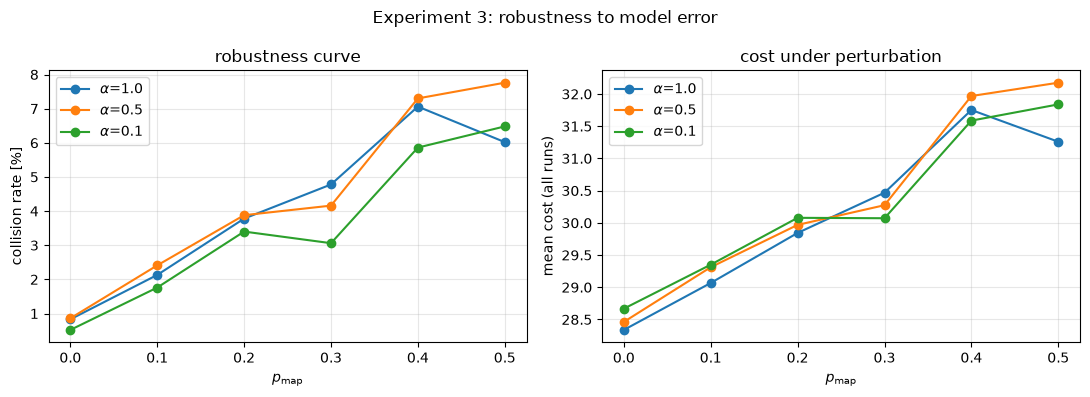

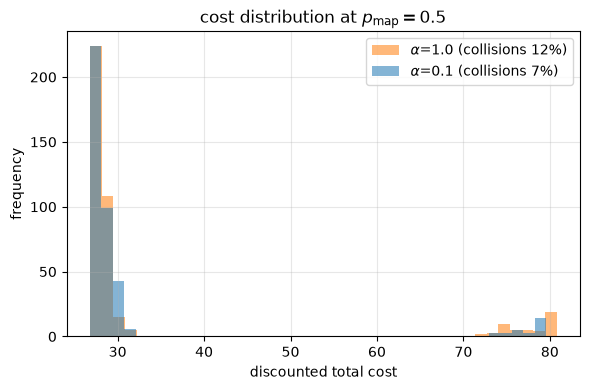

In [19]:
P_MAPS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5] # probability for perturbation of obstacles
ALPHAS_3 = [1.0, 0.5, 0.1]  # note: paper compares only alpha=1 and alpha=0.11
N_NOM, N_PERT, N_RUNS_3 = 10, 20, 100   # nominal maps x perturbations x runs

rows = []
solutions = {}  # seed -> (m, mdp, res), for the histogram (build dict of the mdps and their solution for different seeds)

for seed in range(N_NOM):
    m, mdp, res = build_and_solve(seed) # policy calculated once on the nominal map
    solutions[seed] = (m, mdp, res)
    print(f"  map {seed} solved ({res['iterations']} sweeps)")
    for p_map in P_MAPS:
        for k in range(N_PERT):
            mdp_p = mdp_from_map(perturb_map(m, p_map=p_map, seed=k))
            for alpha in ALPHAS_3:
                s = simulate(res, mdp, alpha, n_runs=N_RUNS_3, seed=7000+k,
                             mdp_eval=mdp_p)    # policy nominal, dynamics perturbed
                rows.append(dict(
                    seed=seed, p_map=p_map, pert=k, alpha=alpha,
                    cost=s["mean_cost"],
                    collision_rate=s["failure_rate"],
                    timeout_rate=s["timeout_rate"]))

exp3 = pd.DataFrame(rows)

# table 
tab3 = (exp3.groupby(["p_map", "alpha"])
             .agg(cost=("cost", "mean"),
                  collision_rate=("collision_rate", "mean"),
                  timeout_rate=("timeout_rate", "mean"))
             .round(4))
print(f"\nExperiment 3 - {N_NOM} nominal maps, {N_PERT} perturbations, "
      f"{N_RUNS_3} runs per combination")
print(tab3.to_string())

# Plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for alpha in ALPHAS_3:
    g = tab3.xs(alpha, level="alpha")   # select only the rows of the respective alpha from tab3
    axes[0].plot(g.index, 100*g["collision_rate"], "o-", label=fr"$\alpha$={alpha}")    # maps p_map against collision rate
    axes[1].plot(g.index, g["cost"], "o-", label=fr"$\alpha$={alpha}")  # maps p_map against cost
axes[0].set_ylabel("collision rate [%]"); axes[0].set_title("robustness curve")
axes[1].set_ylabel("mean cost (all runs)"); axes[1].set_title("cost under perturbation")
for ax in axes:
    ax.set_xlabel(r"$p_{\rm map}$"); ax.grid(alpha=.3); ax.legend()
fig.suptitle("Experiment 3: robustness to model error")
fig.tight_layout(); plt.show()

# cost histogram at maximum perturbation (cf. figure 1 (right) in the paper)
m0, mdp0, res0 = solutions[0]   # create histogram based on the first random map/mdp and its solution
mdp0_p = mdp_from_map(perturb_map(m0, p_map=0.5, seed=0))   # create mdp with p_map=0.5 (max perturbation)
fig, ax = plt.subplots(figsize=(6, 4))
for alpha, color in [(1.0, "C1"), (0.1, "C0")]: # do monte-carlo-runs for alpha=1.0 and alpha=0.1 -> two different colours in the histogram
    s = simulate(res0, mdp0, alpha, n_runs=400, seed=11, mdp_eval=mdp0_p)
    ax.hist(s["costs"], bins=40, alpha=.55, color=color,
            label=fr"$\alpha$={alpha} (collisions {100*s['failure_rate']:.0f}%)")
ax.set_xlabel("discounted total cost"); ax.set_ylabel("frequency")
ax.set_title(r"cost distribution at $p_{\rm map}=0.5$"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

## 8.4 Creation of pretty plots with value function and paths on a wall map with three gaps

14 obstacles, 685 sweeps, bound 4.9e-05


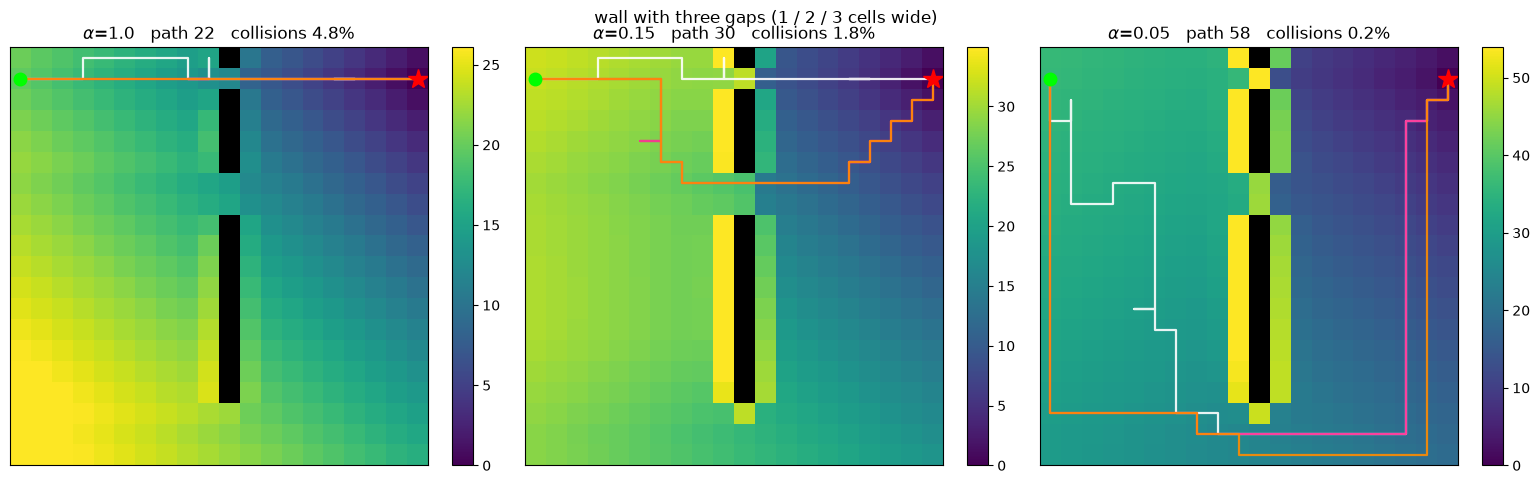

In [20]:
from matplotlib.colors import ListedColormap

N_PATHS = 3 # trajectories per panel
PATH_COLORS = ["white", "#ff2d95", "#ff8c00"]
WALL_COL = 10
GAP_ROWS = {1, 6, 7, 17, 18, 19}    # gaps 1 / 2 / 3 cells wide
ALPHAS_WALL = [1.0, 0.15, 0.05]

def sample_path(res, mdp, alpha, seed, max_steps=400):  # function that returns the realized path through an mdp (for a certain prob. seed)
    """Eine Trajektorie unter der optimalen Policy; gibt die besuchten Zellen zurueck."""
    V, Y = res["V"], res["Y"]
    P, C, gamma = mdp["P"], mdp["C"], mdp["gamma"]
    segs, supp = segments(V, Y), support(P)
    cell_of = {x: rc for rc, x in mdp["index"].items()}
    rng = np.random.default_rng(seed)

    x, y = mdp["index"][mdp["map"].start], alpha
    path = [mdp["map"].start]
    for _ in range(max_steps):
        a, y_next = greedy_policy(x, y, V, Y, P, C, gamma, segs=segs)
        S = supp[a][x]
        x = int(rng.choice(S, p=P[a, x, S]))
        if x in (mdp["GOAL"], mdp["DEAD"]):
            break
        y = y_next.get(x, 0.0)
        path.append(cell_of[x])
    return path

def value_grid(res, mdp, alpha):
    """V(x,alpha) als (H,W)-Array; Hindernisse werden maskiert."""
    H, W = mdp["map"].H, mdp["map"].W
    G = np.full((H, W), np.nan) # initialize value grid
    for rc, x in mdp["index"].items():
        if rc not in mdp["map"].obstacles:  # get value of "field" if its no obstacle
            G[rc] = value_at(x, alpha, res["V"], res["Y"])
    return G

m_wall = Map(20, 20, frozenset((r, WALL_COL) for r in range(20) if r not in GAP_ROWS),
             (1, 0), (1, 19))   # start and goal in the same row
mdp_wall = mdp_from_map(m_wall)
res_wall = cvar_value_iteration(mdp_wall["P"], mdp_wall["C"],
                                gamma=PARAMS["gamma"], tol=TOL)
print(f"{len(m_wall.obstacles)} obstacles, {res_wall['iterations']} sweeps, "
      f"bound {res_wall['bound']:.1e}")

obst_wall = np.zeros((m_wall.H, m_wall.W))
for r, c in m_wall.obstacles:
    obst_wall[r, c] = 1.0

fig, axes = plt.subplots(1, len(ALPHAS_WALL), figsize=(5.2*len(ALPHAS_WALL), 4.8))
for ax, alpha in zip(axes, ALPHAS_WALL):
    G = value_grid(res_wall, mdp_wall, alpha)
    im = ax.imshow(G, cmap="viridis", vmax=np.nanpercentile(G, 97))
    ax.imshow(np.ma.masked_where(obst_wall == 0, obst_wall),
              cmap=ListedColormap(["black"]), vmin=0, vmax=1)
    for k in range(N_PATHS):
        path = sample_path(res_wall, mdp_wall, alpha, seed=k)
        ax.plot([c for _, c in path], [r for r, _ in path],
                lw=1.6, alpha=.9, color=PATH_COLORS[k % len(PATH_COLORS)])
    ax.plot(m_wall.start[1], m_wall.start[0], "o", color="lime", ms=9)
    ax.plot(m_wall.goal[1], m_wall.goal[0], "*", color="red", ms=15)
    s = simulate(res_wall, mdp_wall, alpha, n_runs=500, seed=3)
    ax.set_title(fr"$\alpha$={alpha}   path {s['mean_length_success']:.0f}   "
                 f"collisions {100*s['failure_rate']:.1f}%")
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=.046)
fig.suptitle("wall with three gaps (1 / 2 / 3 cells wide)")
fig.tight_layout(); plt.show()

## 8.5 Short comparison of Waterfilling method and Linear Programming method for sub-max-problem

This short experiment shows the difference in speed between Waterfill (vectorized and not vectorized) and Linear Programming for solving the sub-maximization problem.

In [21]:
def sweep_loop(V, Y, P, C, g, supp, lp):    # defines a bellman sweep unvectorized for lp and waterfill (on the same framework to have a fair comparison -> hence this loop variant (for waterfill) only looses the sorting over all y)
    segs = segments(V, Y); out = []
    for x in range(P.shape[1]):
        ys = Y[x]; best = np.full(len(ys), np.inf)
        for a in range(P.shape[0]):
            S = supp[a][x]; pr = P[a, x, S]; m0 = max(V[s][0] for s in S)
            sub = [m0 if y == 0 else (subproblem_lp(y, pr, S, V, Y) if lp else
                   subproblem_waterfill(y, pr, S, V, Y, segs=segs)) for y in ys]
            best = np.minimum(best, C[x, a] + g*np.array(sub))
        out.append(best)
    return out

rows = []
for seed in range(2):
    mdp = mdp_from_map(make_map(seed, obst_frac=PARAMS["obst_frac"]))
    P, C, g = mdp["P"], mdp["C"], mdp["gamma"]
    nX, supp = P.shape[1], support(P)
    Y = [starting_grid(21, 2.067) for _ in range(nX)]
    V = [np.zeros(21) for _ in range(nX)]
    for _ in range(30):
        V = bellman_sweep(V, Y, P, C, g, supp)
    out = {}
    for k, f in [("LP", lambda: sweep_loop(V, Y, P, C, g, supp, True)),
                 ("waterfill loop", lambda: sweep_loop(V, Y, P, C, g, supp, False)),
                 ("waterfill vectorised", lambda: bellman_sweep(V, Y, P, C, g, supp))]:
        t = time.perf_counter(); r = f(); out[k] = (time.perf_counter() - t, r)
    rows.append({k: v[0] for k, v in out.items()} | {"max|diff|": max(
        np.max(np.abs(a - b)) for a, b in zip(out["LP"][1], out["waterfill vectorised"][1]))})  # max diff is the biggest difference between the sweep result of waterfill vect and lp

bench = pd.DataFrame(rows, index=[f"map {s}" for s in range(len(rows))])
bench["LP / vect."] = bench["LP"] / bench["waterfill vectorised"]
bench["loop / vect."] = bench["waterfill loop"] / bench["waterfill vectorised"]
print(bench.round(4).to_string())

            LP  waterfill loop  waterfill vectorised  max|diff|  LP / vect.  loop / vect.
map 0  27.0025          0.3970                0.0302     0.0285    894.4552       13.1500
map 1  28.5531          0.4038                0.0302     0.0555    945.1642       13.3659


---

# 9 - Final notes

1. Every randomness is created with an explicit seed (`make_map`, `perturb_map`, `simulate`); all tables and results are reproducible

